📊 Telecom X – Análise de Evasão de Clientes (Churn)

🎯 Objetivo



Este projeto tem como objetivo analisar os dados de clientes da Telecom X para identificar fatores que influenciam o cancelamento de serviços (Churn).

A partir da análise exploratória dos dados, buscamos encontrar padrões que ajudem a empresa a desenvolver estratégias para reduzir a evasão de clientes.

## 📘 Dicionário de Dados

O conjunto de dados utilizado contém informações sobre clientes da Telecom X.

Principais variáveis utilizadas na análise:

### 👤 Informações do cliente
- **customerID**: identificador único do cliente
- **tenure**: tempo de permanência do cliente na empresa

### 💳 Informações da conta
- **Contract**: tipo de contrato do cliente
- **PaymentMethod**: método de pagamento
- **Charges.Monthly**: valor mensal pago pelo cliente
- **Charges.Total**: valor total pago pelo cliente

### 🌐 Serviços contratados
- **InternetService**: tipo de serviço de internet
- **OnlineSecurity**: serviço de segurança online
- **TechSupport**: suporte técnico

### ⚠️ Churn
- **Churn**: indica se o cliente cancelou o serviço

## 📌 Extração

Nesta etapa realizamos a coleta dos dados a partir de um arquivo JSON disponível em um repositório no GitHub.

In [28]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/refs/heads/main/TelecomX_Data.json"
dados = pd.read_json(url)

df = pd.json_normalize(dados.to_dict(orient='records'))

df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")
df["account.Charges.Monthly"] = pd.to_numeric(df["account.Charges.Monthly"], errors="coerce")

# Exibe as primeiras linhas para confirmar que df foi definido
display(df.head())

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## 🔧 Transformação

Nesta etapa os dados são organizados e preparados para análise. Realizamos a normalização do JSON e tratamos valores ausentes.

In [29]:
df = pd.json_normalize(dados.to_dict(orient='records'))

df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [30]:
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

df["account.Charges.Monthly"] = pd.to_numeric(df["account.Charges.Monthly"], errors="coerce")

In [31]:
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

In [32]:
# verificar estrutura do dataset
df.info()

# verificar valores ausentes
df.isnull().sum()

# verificar duplicados
df.duplicated().sum()

# verificar valores únicos em colunas categóricas
df.select_dtypes(include="object").nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

,0
customerID,7267
Churn,3
customer.gender,2
customer.Partner,2
customer.Dependents,2
phone.PhoneService,2
phone.MultipleLines,3
internet.InternetService,3
internet.OnlineSecurity,3
internet.OnlineBackup,3


Nesta etapa verificamos possíveis problemas nos dados que podem afetar a análise, como valores ausentes, registros duplicados, erros de formatação e inconsistências nas categorias.
Essa verificação é essencial para garantir que os dados estejam prontos para as etapas seguintes.

In [33]:
# remover duplicados
df = df.drop_duplicates()

# converter valores numéricos
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

# remover valores nulos
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7256 non-null   object 
 2   customer.gender            7256 non-null   object 
 3   customer.SeniorCitizen     7256 non-null   int64  
 4   customer.Partner           7256 non-null   object 
 5   customer.Dependents        7256 non-null   object 
 6   customer.tenure            7256 non-null   int64  
 7   phone.PhoneService         7256 non-null   object 
 8   phone.MultipleLines        7256 non-null   object 
 9   internet.InternetService   7256 non-null   object 
 10  internet.OnlineSecurity    7256 non-null   object 
 11  internet.OnlineBackup      7256 non-null   object 
 12  internet.DeviceProtection  7256 non-null   object 
 13  internet.TechSupport       7256 non-null   object 
 1

Após identificar inconsistências nos dados, foram realizadas as correções necessárias. Valores duplicados foram removidos e colunas numéricas foram convertidas para o tipo correto.
Também foram tratados valores ausentes para garantir que o dataset esteja consistente para análise.

In [34]:
df["Contas_Diarias"] = df["account.Charges.Monthly"] / 30

df[["account.Charges.Monthly","Contas_Diarias"]].head()

,account.Charges.Monthly,Contas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


Para obter uma visão mais detalhada do comportamento de gastos dos clientes, foi criada a coluna "Contas_Diarias".
Ela representa o valor médio gasto por dia, calculado a partir do faturamento mensal dividido por 30.

In [35]:
# converter churn para binário
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

# padronizar colunas
df = df.rename(columns={
"account.Contract":"Contrato",
"account.PaymentMethod":"Metodo_Pagamento",
"account.Charges.Monthly":"Gasto_Mensal",
"account.Charges.Total":"Gasto_Total",
"customer.tenure":"Tempo_Cliente"
})

Foi realizada a padronização dos dados para facilitar a análise.

Valores textuais como "Yes" e "No" foram convertidos para formato binário (1 e 0). Além disso, algumas colunas foram renomeadas para tornar os dados mais claros e compreensíveis.

## 📊 Análise Exploratória de Dados

A análise exploratória permite identificar padrões e relações entre as variáveis que podem influenciar o cancelamento de clientes.

In [36]:
df.describe()


,Churn,customer.SeniorCitizen,Tempo_Cliente,Gasto_Mensal,Gasto_Total,Contas_Diarias
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,32.395535,64.755423,2280.634213,2.158514
std,0.441782,0.3693,24.558067,30.125739,2268.632997,1.004191
min,0.000000,0.0000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,0.0000,9.000000,35.450000,400.225000,1.181667
50%,0.000000,0.0000,29.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.0000,55.000000,89.900000,3785.300000,2.996667
max,1.000000,1.0000,72.000000,118.750000,8684.800000,3.958333


In [37]:
df[["Tempo_Cliente","Gasto_Mensal","Gasto_Total","Contas_Diarias"]].describe()

,Tempo_Cliente,Gasto_Mensal,Gasto_Total,Contas_Diarias
count,7256.000000,7256.000000,7256.000000,7256.000000
mean,32.395535,64.755423,2280.634213,2.158514
std,24.558067,30.125739,2268.632997,1.004191
min,1.000000,18.250000,18.800000,0.608333
25%,9.000000,35.450000,400.225000,1.181667
50%,29.000000,70.300000,1391.000000,2.343333
75%,55.000000,89.900000,3785.300000,2.996667
max,72.000000,118.750000,8684.800000,3.958333


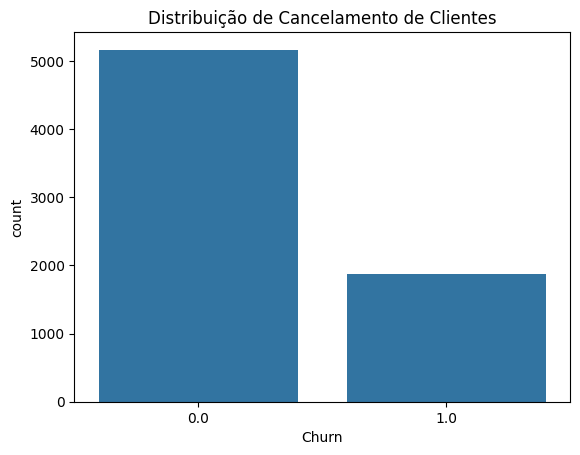

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Churn", data=df)

plt.title("Distribuição de Cancelamento de Clientes")

plt.show()


Nesta etapa analisamos a proporção de clientes que permaneceram na empresa e aqueles que cancelaram o serviço.

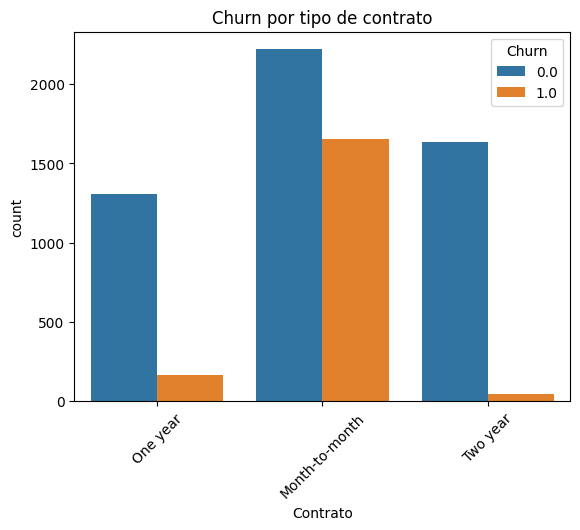

In [39]:
sns.countplot(x="Contrato", hue="Churn", data=df)

plt.xticks(rotation=45)

plt.title("Churn por tipo de contrato")

plt.show()

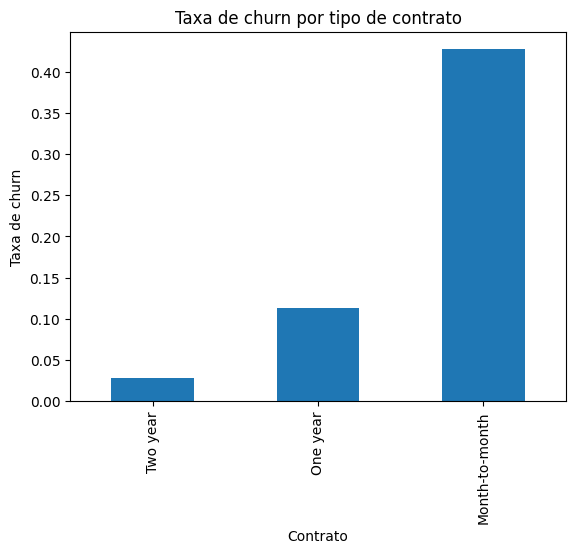

In [40]:
taxa = df.groupby("Contrato")["Churn"].mean().sort_values()

taxa.plot(kind="bar")

plt.title("Taxa de churn por tipo de contrato")

plt.ylabel("Taxa de churn")

plt.show()

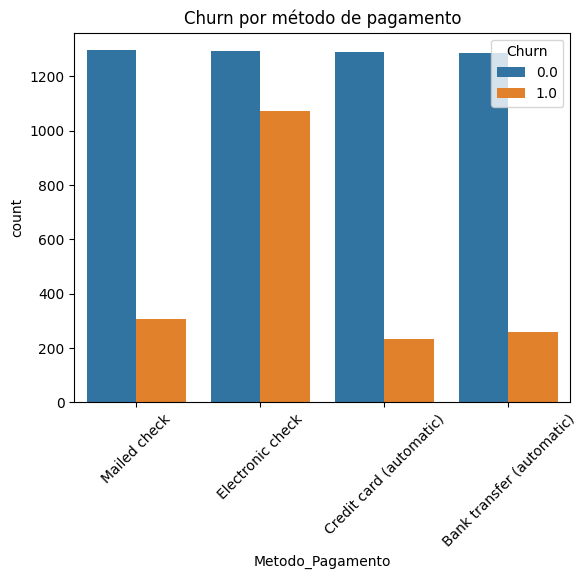

In [41]:
sns.countplot(x="Metodo_Pagamento", hue="Churn", data=df)

plt.xticks(rotation=45)

plt.title("Churn por método de pagamento")

plt.show()

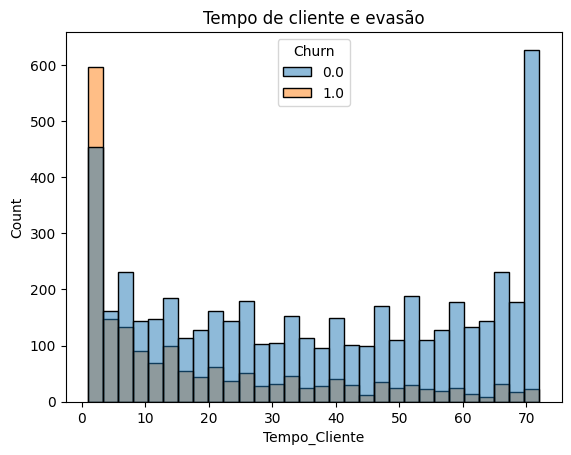

In [42]:
sns.histplot(data=df, x="Tempo_Cliente", hue="Churn", bins=30)

plt.title("Tempo de cliente e evasão")

plt.show()

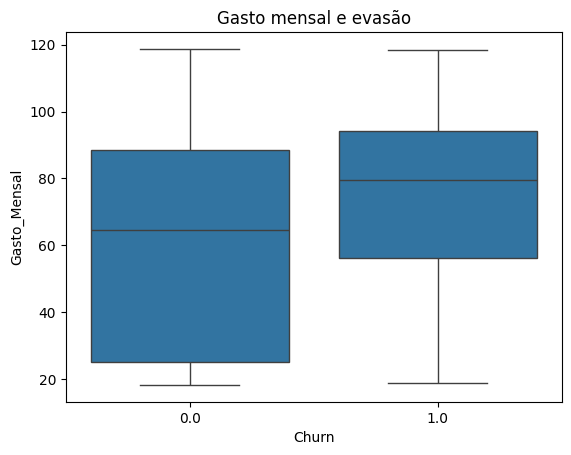

In [43]:
sns.boxplot(x="Churn", y="Gasto_Mensal", data=df)

plt.title("Gasto mensal e evasão")

plt.show()

A análise de variáveis numéricas ajuda a entender se determinados valores estão mais associados à evasão.

In [44]:
servicos = [
"internet.OnlineSecurity",
"internet.OnlineBackup",
"internet.DeviceProtection",
"internet.TechSupport",
"internet.StreamingTV",
"internet.StreamingMovies"
]

df["Qtd_Servicos"] = df[servicos].apply(lambda x: (x == "Yes").sum(), axis=1)

df[["Qtd_Servicos","Churn"]].head()

,Qtd_Servicos,Churn
0,3,0.0
1,1,0.0
2,1,1.0
3,4,1.0
4,2,1.0


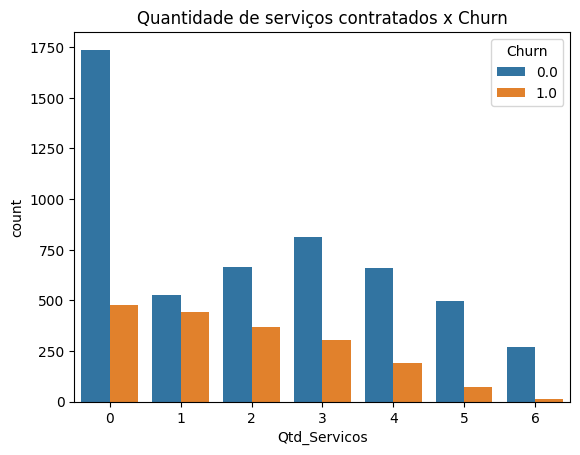

In [45]:
sns.countplot(x="Qtd_Servicos", hue="Churn", data=df)

plt.title("Quantidade de serviços contratados x Churn")

plt.show()

A análise da quantidade de serviços contratados permite avaliar se clientes que possuem menos serviços apresentam maior probabilidade de evasão.

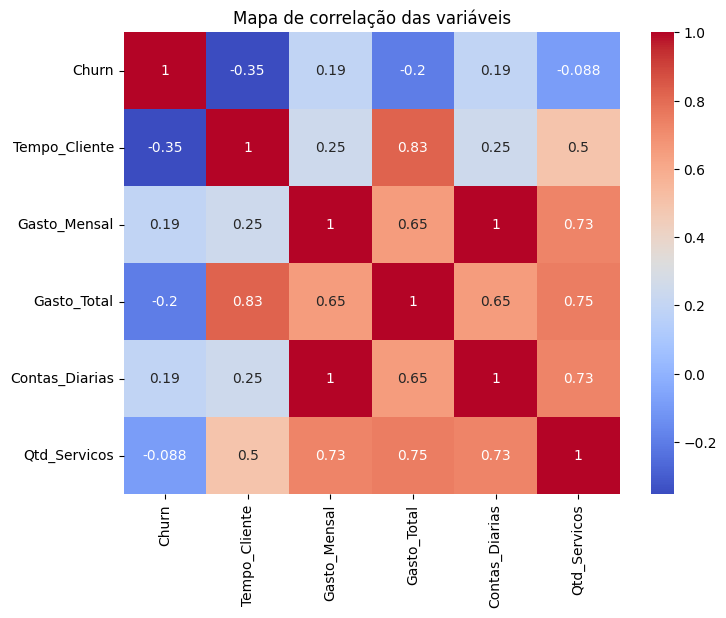

In [46]:
numericas = [
"Churn",
"Tempo_Cliente",
"Gasto_Mensal",
"Gasto_Total",
"Contas_Diarias",
"Qtd_Servicos"
]

plt.figure(figsize=(8,6))

sns.heatmap(df[numericas].corr(), annot=True, cmap="coolwarm")

plt.title("Mapa de correlação das variáveis")

plt.show()

O mapa de correlação ajuda a identificar relações entre variáveis numéricas e a evasão de clientes.

## Principais Insights

Com base na análise realizada, alguns padrões importantes foram identificados:

* Clientes com **contratos mensais** apresentam maior taxa de evasão.
* Clientes com **menor tempo de permanência** possuem maior probabilidade de cancelamento.
* Clientes que possuem **menos serviços contratados** tendem a cancelar com mais frequência.
* O valor mensal e o valor total gasto podem influenciar o comportamento de evasão.

Esses fatores indicam que o relacionamento inicial com o cliente e o nível de engajamento com os serviços da empresa têm forte impacto na permanência do cliente.


# 📄 Relatório Final

O objetivo deste projeto foi analisar os dados de clientes da Telecom X para identificar fatores relacionados à evasão de clientes (Churn).

Durante o processo, foram realizadas etapas de limpeza e preparação dos dados, incluindo tratamento de valores ausentes, padronização de variáveis e criação da variável **Contas_Diarias**, que permite observar o comportamento de gastos dos clientes de forma mais detalhada.

A análise exploratória mostrou que clientes com **contratos mensais**, **menor tempo de permanência** e **menor quantidade de serviços contratados** apresentam maior probabilidade de cancelar o serviço.

Com base nesses resultados, recomenda-se que a empresa invista em estratégias de **fidelização de clientes**, como incentivos para contratos de longo prazo e melhorias na experiência dos clientes nos primeiros meses de uso do serviço.
